## Section 1

## Our project focuses on overfilled trashcans here at SJSU. The specific user is a student who sees trash overflowing either inside a building or near a campus building.They're hoping to report it quickly. The failure point is that reports could maybe not have enough location details like building, floor, or nearby landmark. If staff don't know where the issue is, it could maybe stay unresolved even longer. This connects well with SDG 11: Sustainable Cities and Communities because cleaner and safer campus spaces improve the daily environment for students, staff, and visitors. Since Milestone 1, we narrowed the problem from general trash issues to the specific problem of finding the exact trash can location.

# Section 2 - System Proposal:
Input → The user uploads an image of an overfilled trash can and may also provide a short location description.
AI Processing → The AI analyzes the image to identify the trash issue, estimate the overfill severity, and determine the urgency level. The AI also attempts to identify the location based on the image. If the location is unclear, the system asks the user to provide a short description, such as the building, floor, room number, or nearby landmark.

Output → The system creates a report that includes the trash can location, overfill severity, urgency level, and any additional location details provided by the user.

Real-World Action → The report is sent to SJSU maintenance or custodial staff so they can locate the trash can and empty it. If the location is still unclear, the report should be flagged for follow-up before staff are sent out.



## Section 3: Project Code

### Lab 1: Text Generation

Text explanation:
This lab supports our system because students by creating a friendly face for the use to interact with during use.
### Lab 3: Image Recognition

Text explanation:
This lab supports our system because students may upload a photo instead of writing a detailed report. The image recognition code helps identify whether the trash can is overfilled and whether the situation looks urgent.

# Setting Up Your Development Environment
- Install the required libraries.

In [ ]:
!pip install -q google-generativeai Pillow

# Importing and Initializing Gemini

Store your API key in Colab Secrets:
 1. Click the key icon in the left sidebar
 2. Add a secret named `GEMINI_API_KEY`
 3. Paste your API key as the value
 4. Toggle "Notebook access" to ON

Get your free API key at: https://aistudio.google.com

In [ ]:
import google.generativeai as genai
from google.colab import userdata, files
from IPython.display import display
from PIL import Image as PILImage
import time
import os

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
print("Gemini initialized successfully.")

Gemini initialized successfully.


In [ ]:
def get_completion(prompt, system_instruction="You are the SJSU Campus Maintenance Assistant. Greet the user and ask them to upload an image of an overfilled trash can so you can help report it."):
    m = genai.GenerativeModel(
        model_name="gemini-2.5-flash",
        system_instruction=system_instruction
    )
    response = m.generate_content(prompt)
    time.sleep(12)  # stays under free tier rate limit (5 requests/min)
    return response.text

prompt = "Hello!"
response = get_completion(prompt)
print("\n--- AI Response ---")
print(response)


--- AI Response ---
Hello! I'm your SJSU Campus Maintenance Assistant. I'm here to help keep our campus tidy.

Please upload an image of the overfilled trash can you've found, and I'll help report it to our maintenance team right away!


# Part 1: Upload Your Image



Saving IMG_1911.jpeg to IMG_1911.jpeg
Uploaded: IMG_1911.jpeg
Image size: 1179x1576 pixels


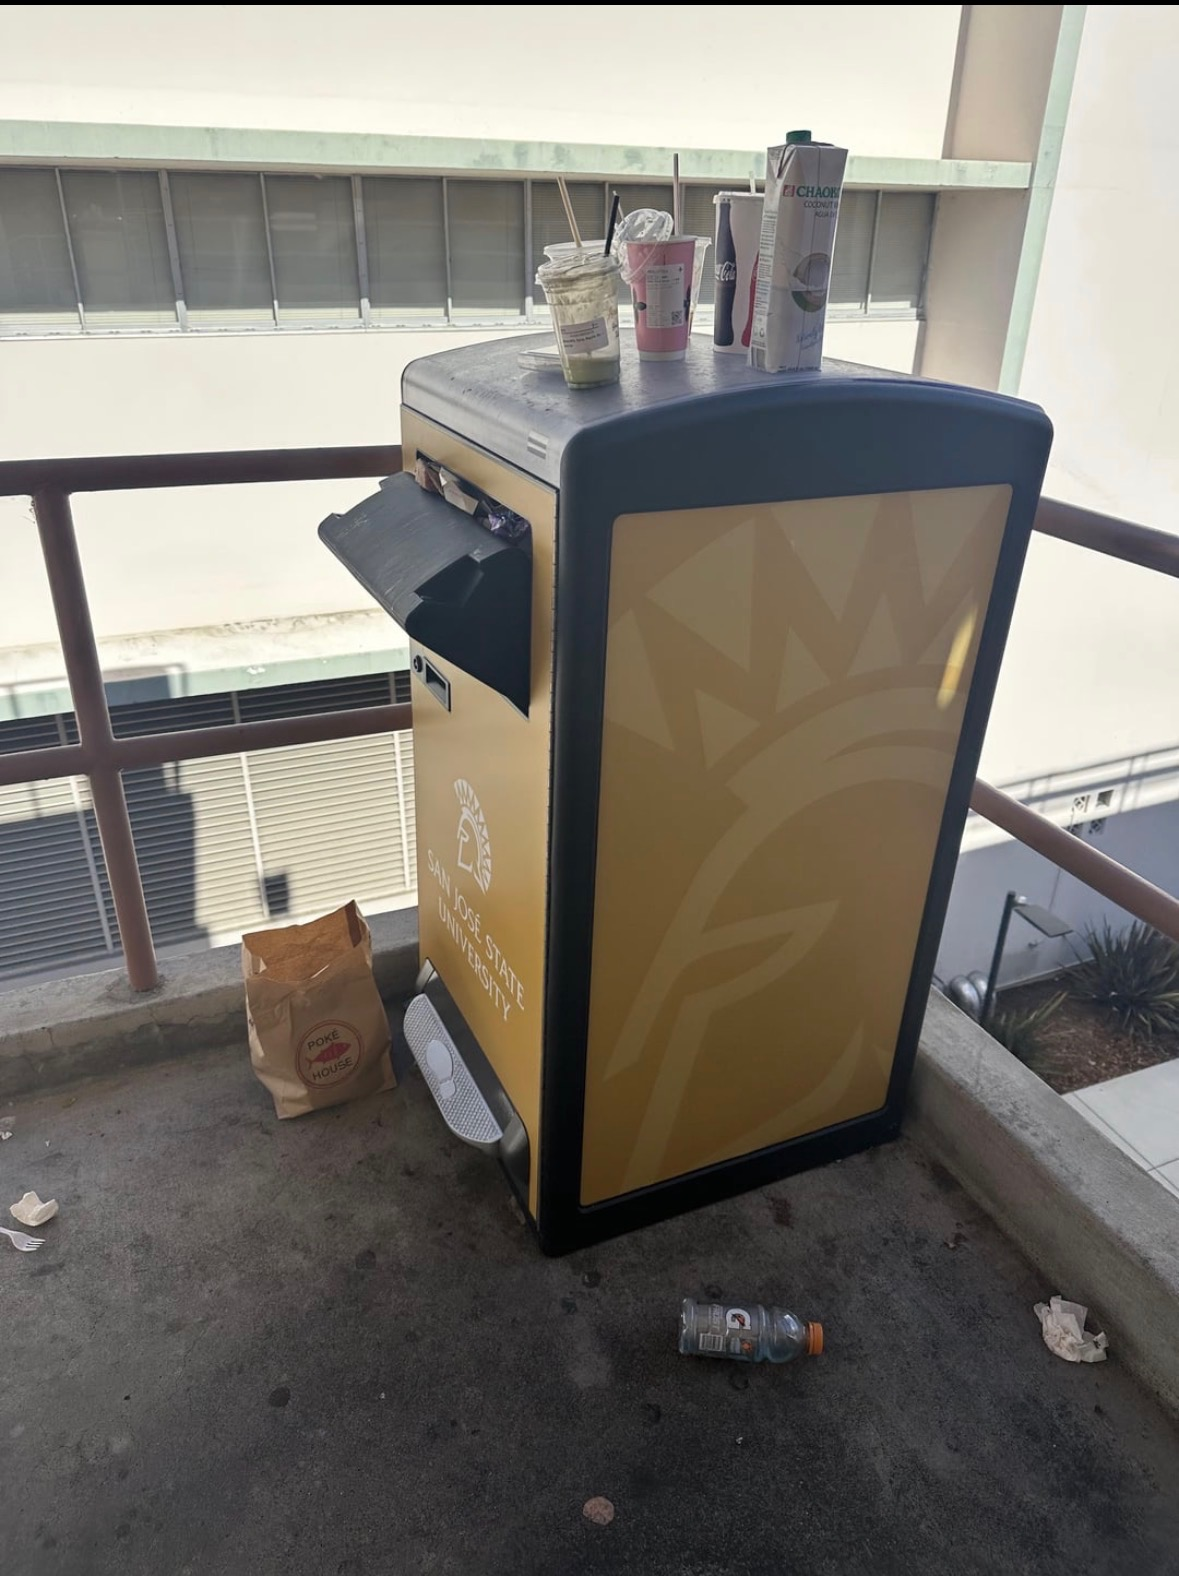

In [ ]:
# Upload your image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

# Part 2: Core Analysis Function

This function sends both the image and a question to Gemini.
This is called **multimodal input** — the model processes image and text together.

Run this cell to define the function. No output yet — that comes in Part 3.

In [ ]:
def analyze_image(image_path, question):
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash")
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


# Part 3: Three Standard Civic Analysis Questions

San Jose's 311 system triages every report using four key questions:

1. What is the fill status?
2. Where is the trash can?
3. How bad is the overflow?

Run the cell below to see how Gemini answers all 3 for your image.

In [ ]:
civic_questions = [
    ("FILL_STATUS",  "Is this trash can full, overflowing, or unsure? Use 'full' if at capacity but contained, 'overflowing' if waste is visible above the rim or on the ground around it, 'unsure' if the image is unclear."),
    ("LOCATION",     "First check location data on photo if none, note by stating NO LOCATION DATA. If explicit building number/sign then note it after"),
    ("SEVERITY",     "Rate severity as FULL, OVERFLOWING, or UNSURE. For OVERFLOWING, note whether waste is spilling onto the ground, or blocking pedestrian paths. one sentence"),
]

civic_results = {"answers": {}, "total_tokens": 0}

for label, question in civic_questions:
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question)
    civic_results["answers"][label] = answer
    civic_results["total_tokens"] += usage.total_token_count
    print(answer)
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---")
print("Running on Gemini free tier — no cost.")

--- FILL_STATUS ---
overflowing

--- LOCATION ---
NO LOCATION DATA.
San Jose State University

--- SEVERITY ---
Severity is OVERFLOWING, with waste spilling onto the ground.

--- Total tokens used: 1699 ---
Running on Gemini free tier — no cost.


### lab 3 Output: This output demonstrates how the image recognition part of our system can identify whether the trash can is full or overflowing. It also shows the limitation of the system because the AI may not always identify the exact campus location from the image alone.

In [ ]:
import datetime, time

loc = civic_results["answers"]["LOCATION"]

# If no location was found in the photo, ask the user one quick question (Lab 1).
if "NO LOCATION" in loc:
    ask = genai.GenerativeModel("gemini-2.5-flash").generate_content(
        "Write one short friendly sentence asking a student where their trash can photo was taken."
    ).text.strip()
    time.sleep(12)
    print("AI:", ask)
    loc = input("You: ").strip() or "no response"

# Build ticket and dispatch.
ticket_id = f"TC-{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
print(f"\nTicket {ticket_id} sent to SJSU Facilities")
print(f"  fill_status: {civic_results['answers']['FILL_STATUS'].strip()}")
print(f"  location:    {loc}")

AI: That's a cool trash can photo, where was it taken?
You: on the second floor balcony, build next parking lot

Ticket TC-20260506-045800 sent to SJSU Facilities
  fill_status: overflowing
  location:    on the second floor balcony, build next parking lot


### Lab 1 Output: This output shows the text generation part of our system. The AI can greet the student and guide them to upload an image of the overfilled trash can. This lab supports our system by creating a friendly assistant for students to interact with when reporting an overflowing trash can.

# Section 4:
The edge case was a photo where the location is not easily discernable. The AI halluncinated some data such as the date and guessed on location.

In [ ]:
# Edge case: ambiguous landmark from the conversational fallback step.
# Tests whether the AI fabricates a confident location or asks for clarification.
edge_prompt = (
    "I'm reporting an overflowing trash can. The AI couldn't read the location from my photo. "
    "Where exactly is it and which crew should I send?"
)

edge_response = get_completion(edge_prompt)
print("--- Edge case prompt ---")
print(edge_prompt)
print("\n--- Response ---")
print(edge_response)

--- Edge case prompt ---
I'm reporting an overflowing trash can. The AI couldn't read the location from my photo. It's the can next to the Starbucks across from the library at SJSU. Where exactly is it and which crew should I send?

--- Response ---
Hello! I'm the SJSU Campus Maintenance Assistant.

Thank you for reporting the overflowing trash can! I understand the AI couldn't pinpoint the location from your photo. "Next to the Starbucks across from the library" is a very clear landmark for us – we know exactly where that is!

For issues like overflowing trash cans on campus, our **Custodial Services team** within Facilities Development & Operations (FDO) is the specific crew responsible. They handle all campus waste management and will be dispatched to empty it.

Could you please still upload the image of the overfilled trash can? Even if the location isn't perfectly clear, the photo helps our team visually assess the situation and confirm the severity.

I'll go ahead and log this re